# 🩺💰📈 Health Costs Linear Regression

Predict insurance `expenses` from `age, sex, bmi, children, smoker, region`.

Target: `model.evaluate` on `test_dataset` must return **Mean Absolute Error < 3500**.

Architecture: Normalization → Dense(relu) → Dense(relu) → Dense(1, linear). See project README / diagram for reasoning.

## 1. *Libraries importation*

In [ ]:
!pip install -q git+https://github.com/tensorflow/docs

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import urllib.request
print(tf.__version__)


2.21.0


## 2. *Import data*

In [3]:
headers = {"User-Agent": "Mozilla/5.0"}

for url, filename in [
    ("https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv", "insurance.csv"),
]:
    # Download the file from `url` and save it locally under `filename`
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req) as response, open(filename, "wb") as out_file:
        out_file.write(response.read())

file_path_dataset = "insurance.csv"


## 3. *Load data*

In [5]:
dataset = pd.read_csv("insurance.csv")
dataset.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [7]:
dataset.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [8]:
dataset.shape

(1338, 7)

In [9]:
dataset.info()    # check dtypes, spot which columns are categorical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
dataset.describe()  # Get a feel for numeric ranges (age, bmi, expenses)

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [11]:
dataset.isna().sum()  #  check for missing values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

## 4. *Data Visualisation*

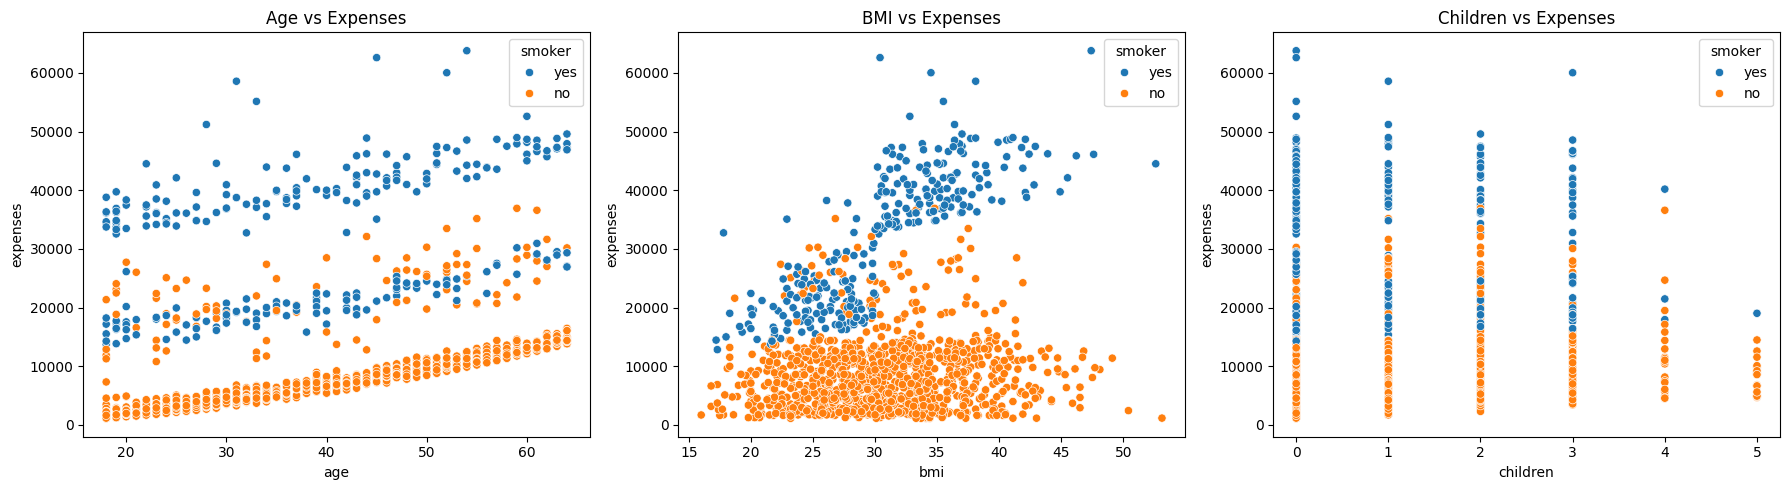

In [12]:
# scatter plots to visualize relationships between features and target variable (expenses)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=dataset, x="age", y="expenses", hue="smoker", ax=axes[0])
axes[0].set_title("Age vs Expenses")

sns.scatterplot(data=dataset, x="bmi", y="expenses", hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs Expenses")

sns.scatterplot(data=dataset, x="children", y="expenses", hue="smoker", ax=axes[2])
axes[2].set_title("Children vs Expenses")

plt.tight_layout()
plt.show()

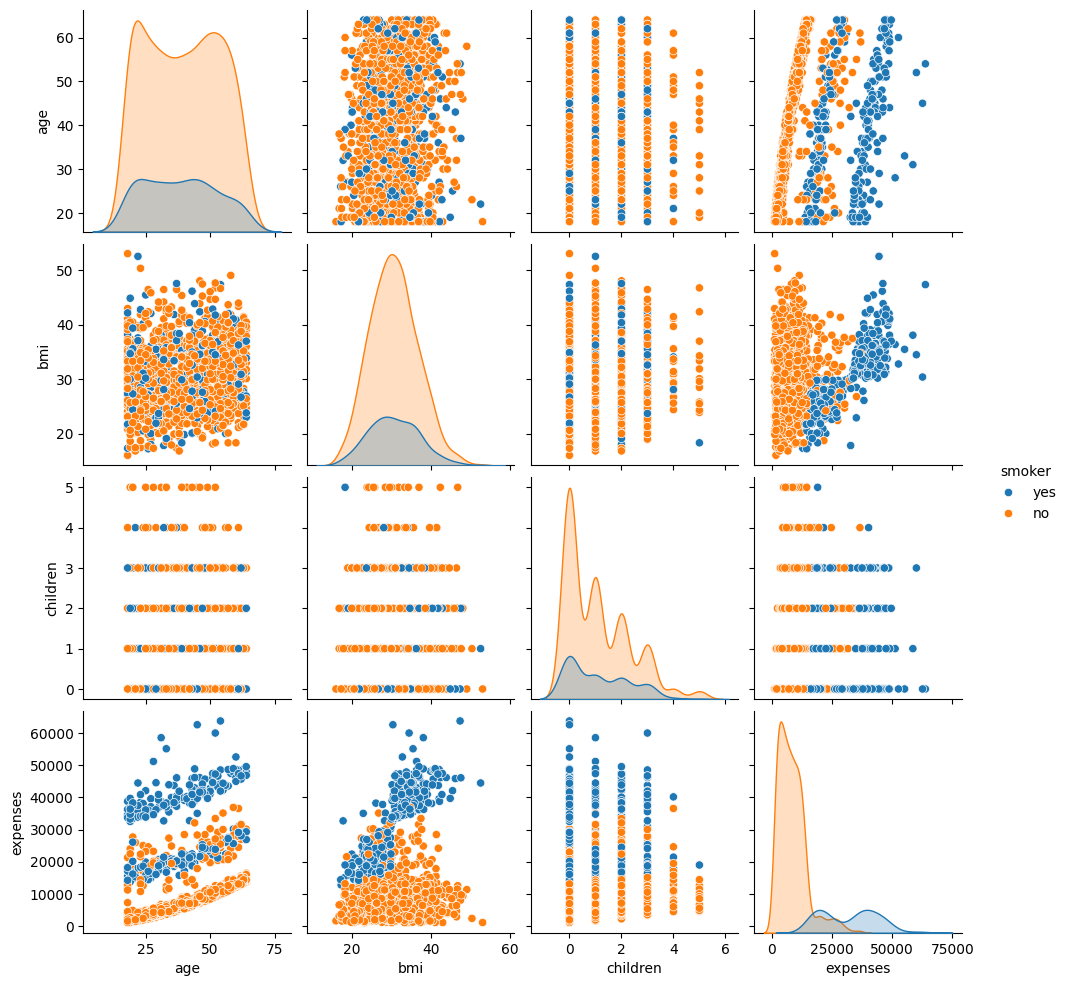

In [13]:
# pairplot to visualize relationships between features and target variable (expenses)
sns.pairplot(dataset, hue="smoker", vars=["age", "bmi", "children", "expenses"])
plt.show()

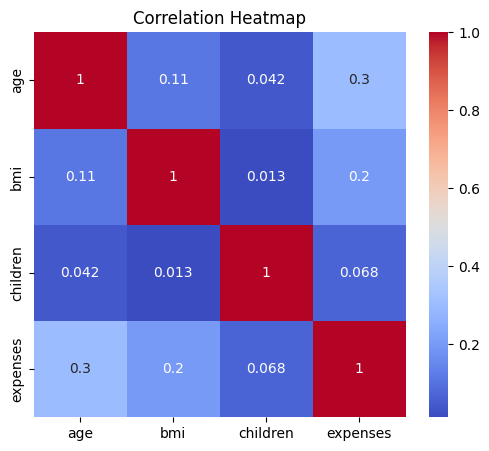

In [14]:
# heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(dataset.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. *Encode categorical columns*

In [33]:
dataset_encoded = dataset.copy()

# Binary mapping for sex and smoker
dataset_encoded["sex"] = dataset_encoded["sex"].map({"male": 0, "female": 1}).astype("float32")
dataset_encoded["smoker"] = dataset_encoded["smoker"].map({"no": 0, "yes": 1}).astype("float32")

# One-hot encoding for region
dataset_encoded = pd.get_dummies(dataset_encoded, columns=["region"], drop_first=True,  dtype="float32")
dataset_encoded["age"] = dataset_encoded["age"].astype("float32")
dataset_encoded["bmi"] = dataset_encoded["bmi"].astype("float32")
dataset_encoded["children"] = dataset_encoded["children"].astype("float32")
dataset_encoded["expenses"] = dataset_encoded["expenses"].astype("float32")

print("\nAfter encoding:")
dataset_encoded.head()


After encoding:


,age,sex,bmi,children,smoker,expenses,region_northwest,region_southeast,region_southwest
0,19.0,1.0,27.900000,0.0,1.0,16884.919922,0.0,0.0,1.0
1,18.0,0.0,33.799999,1.0,0.0,1725.550049,0.0,1.0,0.0
2,28.0,0.0,33.000000,3.0,0.0,4449.459961,0.0,1.0,0.0
3,33.0,0.0,22.700001,0.0,0.0,21984.470703,1.0,0.0,0.0
4,32.0,0.0,28.900000,0.0,0.0,3866.860107,1.0,0.0,0.0


## 6. *Split train / test*

In [34]:
# Get train and test data from dataset_encoded
train_dataset = dataset_encoded.sample(frac=0.8, random_state=0)  # 80% train data
test_dataset = dataset_encoded.drop(train_dataset.index)          # 20% test data


## 7. *Pop off labels*

In [35]:
train_labels = train_dataset.pop('expenses')
test_labels  = test_dataset.pop('expenses')


## 8. *Build the model*

In [41]:
train_dt = np.array(train_dataset)

# Create and adapt the normalization layer
normalization_layer = tf.keras.layers.Normalization(axis=-1, name='normalization')
normalization_layer.adapt(train_dt)

model = tf.keras.Sequential([
    normalization_layer,                             # Normalization layer
    tf.keras.layers.Dense(64, activation='relu'),    # 64 neurons in the first hidden layer
    tf.keras.layers.Dense(16, activation='relu'),    # 16 neurons in the second hidden layer
    tf.keras.layers.Dense(1)                         # Output layer with 1 neuron for regression
])

# Compile the model with Adam optimizer and Mean Absolute 
model.compile(optimizer='adam', loss='mae', metrics=['mae', 'mse'])


## 9. *Train*

In [42]:
# Monitor the validation loss and stop training if it doesn't improve for 10 epochs
monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=10, verbose=1, mode='auto', restore_best_weights=True)

# Train the model
history = model.fit(train_dt, train_labels, validation_split=0.2, epochs=500, batch_size=32, callbacks=[monitor])

Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 12712.8311 - mae: 12712.8311 - mse: 301899776.0000 - val_loss: 14428.3105 - val_mae: 14428.3105 - val_mse: 363325536.0000
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12711.4766 - mae: 12711.4766 - mse: 301863456.0000 - val_loss: 14426.5488 - val_mae: 14426.5488 - val_mse: 363273472.0000
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12709.2197 - mae: 12709.2197 - mse: 301805024.0000 - val_loss: 14423.5645 - val_mae: 14423.5645 - val_mse: 363184832.0000
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12705.5137 - mae: 12705.5137 - mse: 301707808.0000 - val_loss: 14418.7979 - val_mae: 14418.7979 - val_mse: 363045440.0000
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12699.6738 - mae: 12699.6738 - mse: 301553888.0000 - val_loss: 14411.4346 - val_mae: 14411.4346 - val_mse: 362832576.0000
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12690.8057 - mae: 12690.8057 - mse:

## 10. *Plot training loss*

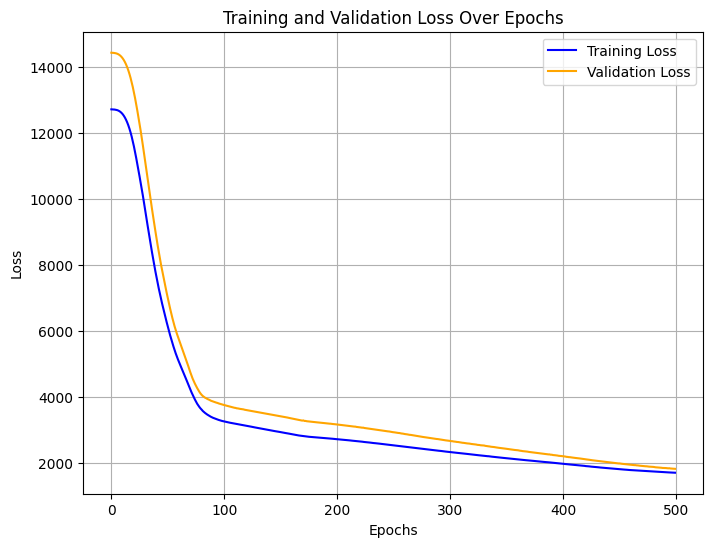

In [43]:
# Extract loss values from the history object
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot the training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(training_loss, label='Training Loss', color='blue')
plt.plot(validation_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## 11. *Final test cell*

9/9 - 0s - 13ms/step - loss: 2552.6021 - mae: 2552.6021 - mse: 34496928.0000
Testing set Mean Abs Error: 2552.60 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


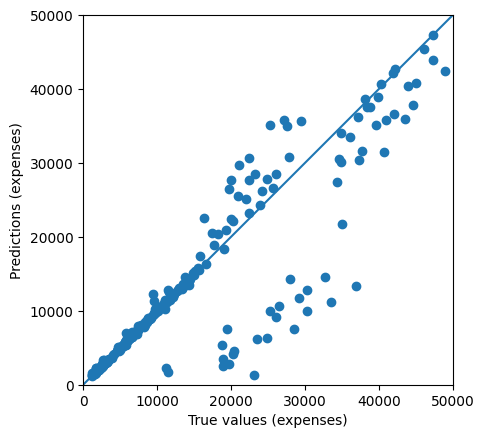

In [44]:
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
